<a href="https://colab.research.google.com/github/akshaybhatt97/365-DAYS-AI-ML-WITH-AKSHAY/blob/main/day_041_gini_vs_entropy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 41/365 — Gini Impurity vs Entropy
## How does a Decision Tree choose the best question to ask?

Yesterday we introduced Decision Trees.

Today we go one level deeper: **how does the tree decide which split is better?**

Two common criteria are:
- **Gini Impurity**
- **Entropy**

Both measure how mixed a node is.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score


## 1. Simple intuition

Suppose a node contains 8 fraud transactions and 2 genuine transactions.

Then:
- p(fraud) = 0.8
- p(genuine) = 0.2


In [2]:
p1=0.8
p2=0.2

gini=1-(p1**2+p2**2)
entropy=-(p1*np.log2(p1)+p2*np.log2(p2))

print("Gini Impurity:",round(gini,3))
print("Entropy:",round(entropy,3))


Gini Impurity: 0.32
Entropy: 0.722


## 2. Compare pure vs mixed nodes

**Gini**

`Gini = 1 - Σ pᵢ²`

**Entropy**

`Entropy = -Σ pᵢ log₂(pᵢ)`

Both are low when a node is pure and high when classes are evenly mixed.


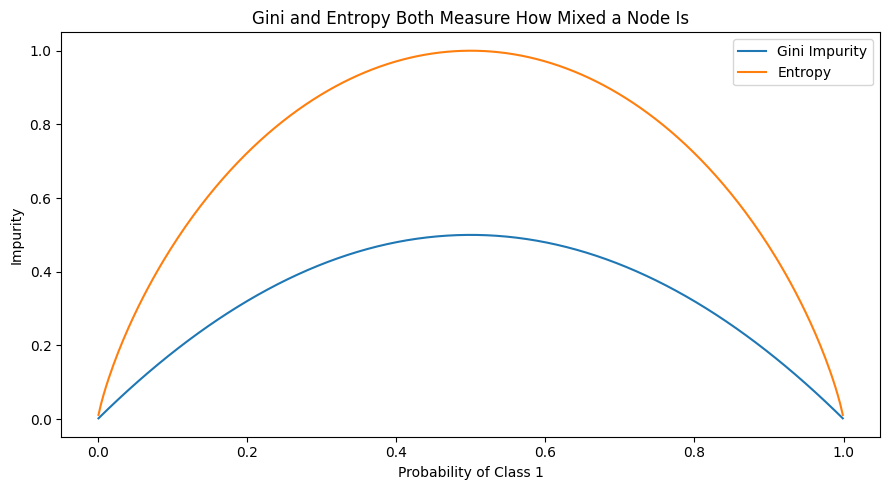

In [3]:
p=np.linspace(0.001,0.999,300)

gini_values=1-(p**2+(1-p)**2)
entropy_values=-(p*np.log2(p)+(1-p)*np.log2(1-p))

plt.figure(figsize=(9,5))
plt.plot(p,gini_values,label="Gini Impurity")
plt.plot(p,entropy_values,label="Entropy")
plt.xlabel("Probability of Class 1")
plt.ylabel("Impurity")
plt.title("Gini and Entropy Both Measure How Mixed a Node Is")
plt.legend()
plt.tight_layout()
plt.show()


## 3. Real dataset experiment

Now we train two trees on the real Iris dataset.

Everything stays the same except the split criterion.


In [5]:
iris=load_iris(as_frame=True)
X=iris.data
y=iris.target

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.25,random_state=42,stratify=y
)

gini_tree=DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    random_state=42
)

entropy_tree=DecisionTreeClassifier(
    criterion="entropy",
    max_depth=3,
    random_state=42
)

gini_tree.fit(X_train,y_train)
entropy_tree.fit(X_train,y_train)

gini_acc=accuracy_score(y_test,gini_tree.predict(X_test))
entropy_acc=accuracy_score(y_test,entropy_tree.predict(X_test))

print("Gini Tree Accuracy:",round(gini_acc,3))
print("Entropy Tree Accuracy:",round(entropy_acc,3))


Gini Tree Accuracy: 0.895
Entropy Tree Accuracy: 0.895


## 4. Compare both criteria


,Criterion,Test Accuracy
0,Gini,0.895
1,Entropy,0.895


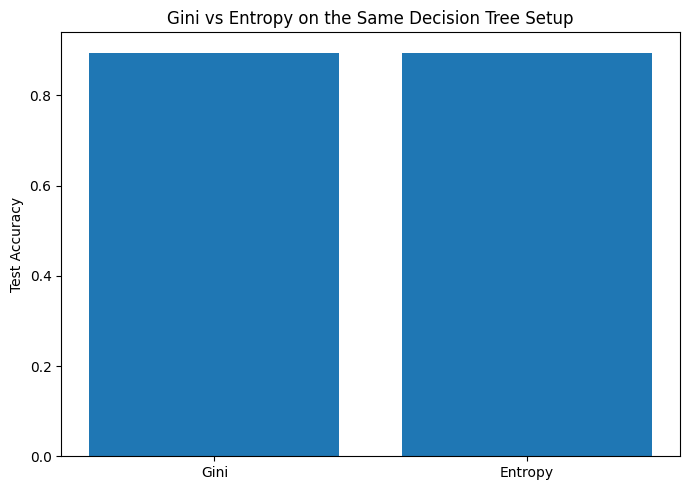

In [6]:
results=pd.DataFrame({
    "Criterion":["Gini","Entropy"],
    "Test Accuracy":[gini_acc,entropy_acc]
})

display(results.round(3))

plt.figure(figsize=(7,5))
plt.bar(results["Criterion"],results["Test Accuracy"])
plt.ylabel("Test Accuracy")
plt.title("Gini vs Entropy on the Same Decision Tree Setup")
plt.tight_layout()
plt.show()


## Enterprise intuition

Imagine a fraud-detection tree deciding whether to split on:

`Transaction Amount > ₹50,000?`

That split is useful only if it creates cleaner groups — for example, one branch containing mostly genuine transactions and another containing a higher concentration of fraud.

Gini or Entropy gives the tree a numerical way to measure how much cleaner the groups become.


## What does this experiment teach?

- Decision Trees do not choose questions randomly.
- They evaluate candidate splits and prefer those that reduce impurity.
- Gini and Entropy are two ways to measure class mixture.
- Lower impurity means a node is more pure.
- In practice, both criteria often produce similar performance.
- The criterion itself is a hyperparameter.

> **A good split is one that turns a mixed group into cleaner, more predictable groups.**


## References

- https://scikit-learn.org/stable/modules/tree.html
- https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html
- https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html
